Logistic Regression — Multiple Features

Logistic regression is a classification algorithm used to predict the probability of a binary outcome (such as Yes/No, Pass/Fail, Disease/No Disease) using one or more input features.

1. Imports

In Python machine learning we use tools from people. We import:

* **Data Helpers:** `pandas` and `numpy` to work with data tables and numbers.

* **Chart Makers:** `matplotlib` and `seaborn` to make pictures.

* **The Main Tool (`sklearn`):** This helps us split data change sizes, train models and check results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

2. Objective

The goal is **Binary Classification**. This is different from regression, which predicts a number like a house price. Here we map input features to a simple yes/no line. The line is then cut by a threshold to decide if someone has heart disease or not.


Build a classification model using all available input features to predict Heart Disease.

Input (X): All columns except the target variable
Output (Y): Heart Disease (binary: Presence / Absence)


3. Data Loading

This is where we bring data from a file into the computers memory. A Pandas DataFrame is like a spreadsheet that can be changed by the computer.


In [2]:
# Load the Heart Disease dataset
def load_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

df = load_dataset('Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


4. Data Exploration

Before using data in math we need to check it.

* `df.shape` shows how rows and columns of data there are.

* `df.describe()` calculates the value and spread of the data. This helps us find mistakes, like a blood pressure of 0.



In [3]:
# Dataset dimensions
df.shape

(270, 14)

In [4]:
# Statistical summary of all numerical columns
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


5. Data Cleaning and Preprocessing

Machine learning algorithms can't handle missing data or words as numbers.

* **Type Changing:** We make sure columns are the type (e.g. text labels are "object" or decimals are "int").

In [5]:
# Check for missing and duplicate values
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Duplicate rows: 0


In [6]:
# Verify and cast column data types as needed
df.dtypes

if df.dtypes['Heart Disease'] != object:  # fixed: compare to object, not 'str'
    df['Heart Disease'] = df['Heart Disease'].astype(str)

if df.dtypes['Age'] != 'int64':
    df['Age'] = df['Age'].astype(int)

# Repeat for remaining columns as needed

6. Encoding

Computers cannot compute the slope of a word like Typical Angina.

* One-Hot Encoding: Converts strings into columns of 1s and 0s.

* Dummy Variable Trap: Eliminates columns.

* Correlation Heatmap: Uses Pearson’s correlation coefficient to identify linear associations.

In [7]:
# One-hot encode all categorical input features
# drop_first=True removes one dummy per category to avoid multicollinearity
# (the 'dummy variable trap') and reduces dimensionality
encoder = pd.get_dummies(df.drop('Heart Disease', axis=1), drop_first=True)
encoder.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3


In [8]:
# Label-encode the target variable: Absence → 0, Presence → 1
le = LabelEncoder()
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


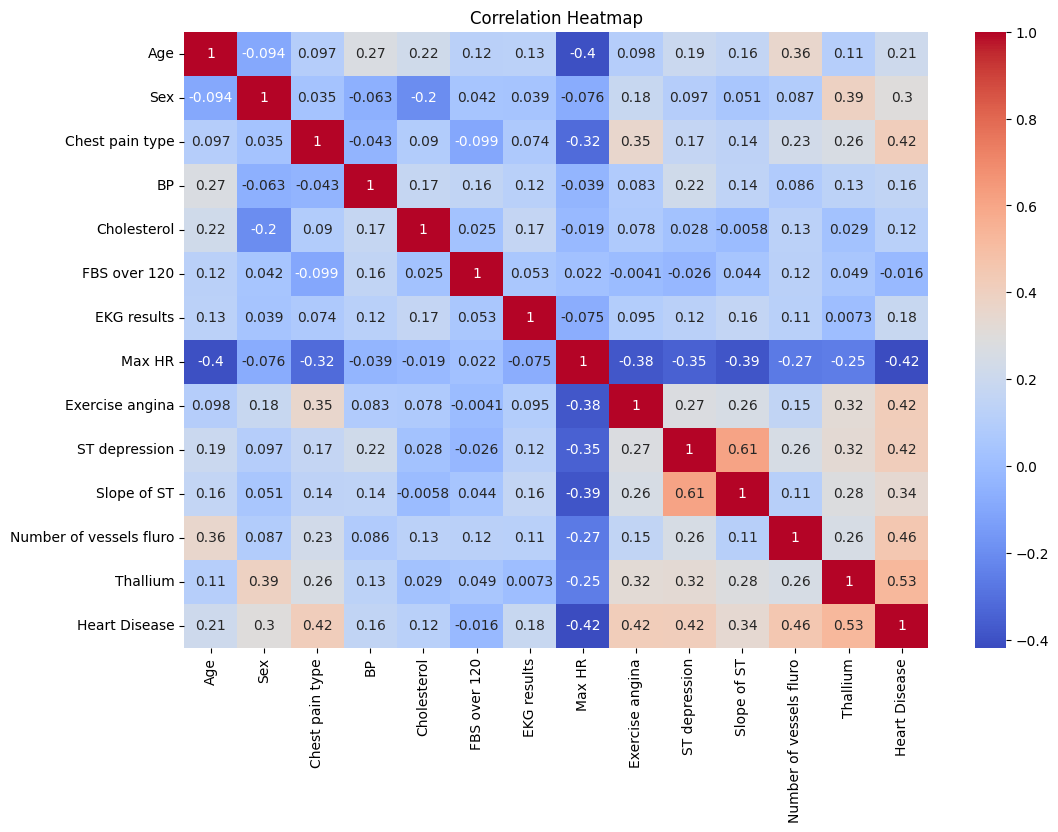

In [9]:
# Combine encoded features with the encoded target and plot a correlation heatmap
encoded_df = pd.concat([encoder, df['Heart Disease']], axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(encoded_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

7. Feature and Target Preparation

Algorithms expect a separation between the predictors and the ground truth.

* X: The -dimensional space used to construct the decision boundary.

* y: Flatted into a 1D array because Scikit-Learn’s loss functions evaluate vector inputs row-by-row against a target array.


In [10]:
# Separate features and target
# .values.ravel() flattens the target to a 1-D array as required by sklearn
features = encoder  # fixed: use one-hot encoded features, not raw df
target   = df['Heart Disease'].values.ravel()

8. Train / Test Split and Feature Scaling

To prevents data memorization. We train on 80% of the data. Hold out 20% to simulate how the model will perform on patients it has never seen before.

Logistic regression relies on descent and distance calculation. Scaling normalizes all features to an standard deviation.

Crucial Rule: We only fit the scaler on the training data to prevent Data Leakage.


In [11]:
# Split into 80 % training and 20 % testing sets
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42  # fixed: target already raveled
)

# Scale features to zero mean and unit variance
# fit_transform on train → transform only on test (avoids data leakage)
scaler      = StandardScaler()
X_tr_scaled = scaler.fit_transform(x_train)
X_te_scaled = scaler.transform(x_test)

print(f'Train shape: {x_train.shape}  |  Test shape: {x_test.shape}')
print(f'\nScaled X_train (first row):\n{X_tr_scaled[0]}')

Train shape: (216, 13)  |  Test shape: (54, 13)

Scaled X_train (first row):
[-0.63296991 -1.52416434 -1.21490572  0.12509482  0.40639114 -0.39380225
 -1.04259375  0.56612833 -0.7367884  -0.9343038   0.66200384 -0.71458405
 -0.90541914]


9. Model Training and Evaluation

Logistic Regression fits a Sigmoid function of the data features

Precision=TP/(TP+FP)

Recall (Sensitivity)=TP/(TP+FN)

F1-Score= (2 x precision x recall)/precision+recall

In [12]:
# Train logistic regression on the scaled training data
log_reg = LogisticRegression()
log_reg.fit(X_tr_scaled, y_train)

# Predict on the scaled test data
y_pred = log_reg.predict(X_te_scaled)

# Full classification report and confusion matrix
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}')

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

Confusion Matrix:
[[31  2]
 [ 3 18]]


In [13]:
# Individual metric breakdown
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

Precision: 0.9000
Recall   : 0.8571
F1 Score : 0.8780


10. Comparison: Single Feature vs. Multiple Feature Model

1) Which model performs better and why?

 The Multiple Feature model holds predictive power. Heart disease is multifactorial. A single-feature model suffers from bias. A multiple-feature model captures the compound weight of compounding risk factors.


2) How does adding more features affect accuracy and recall?

 Accuracy and Recall generally increase, because the algorithm is provided contextual evidence.
 The Catch: If you add variables performance will eventually drop due to overfitting.



3) Trade-off between interpretability and performance

 Single-Feature: Exceptionally easy to interpret. Performs poorly because it oversimplifies reality.
 Multiple-Feature: Offers accuracy, but is harder to visualize. Luckily Logistic Regression is still a white-box algorithm.



Here is a concise breakdown of the theory and operational purpose behind each step of your pipeline.

## 1. Imports


## 2. Objective


## 3. Data Loading


## 4. Data Exploration

## 5. Data Cleaning and Preprocessing



## 6. Encoding

Computers can't understand words like "Typical Angina".

* **One-Hot Encoding:** Changes words into columns of 1s and 0s.

* **Removing Columns:** If a category has two options (e.g. Male/Female) we remove one column to prevent **multicollinearity**.

* **Correlation Chart:** Shows which inputs are related. Strong relationships between inputs and targets mean we have features.

## 7. Feature and Target Preparation

Algorithms need predictors and the correct answer to be separate.

* `X` (Features): This is the space used to make the decision boundary.

* `y` (Target): This is the answer changed into a simple array.

## 8. Train / Test Split and Feature Scaling

* **Train/Test Split:** We use 80% of the data to train. 20% To test. This prevents the model from memorizing the data.

* **Feature Scaling (`StandardScaler`):** This makes all features have the mean and spread. This way the model doesn't think one feature is more important just because its numbers are bigger.

> **Important Rule:** We only change the scaler using the training data. This prevents **Data Leakage**.

## 9. Model Training and Evaluation

Logistic Regression fits a curve to the data.

It checks success using three metrics.

| Metric | Theory Formula | Simple Medical Meaning |

| --- | --- | --- |

**Precision** | $\frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$ | Out of everyone the model flagged as "Sick" how many actually were? |

| **Recall (Sensitivity)** | $\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$ | Out of all the sick people what percentage did the model catch? |

**F1-Score** | $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ | A balanced health metric. |

## 10. Comparison: Feature vs. Multiple Feature Model

### 1) Which model performs better and why?

**The Multiple Feature model** is better. Heart disease has causes. A single-feature model (e.g. using Age*) is not good because it **underfits**. A multiple-feature model captures risk factors.

### 2) How does adding features affect accuracy and recall?

* **Accuracy and Recall generally increase** because the algorithm has evidence.

* **The Catch:** If you add variables performance will drop due to **overfitting**.

### 3) Trade-off, between interpretability and performance

* **Feature:** Easy to understand but performs poorly.

* **Feature:** Offers high accuracy but is harder to visualize. Luckily Logistic Regression shows the weights of each feature.